# Predykcja Market Value - Fortune 500

Cel: przewidziec wartosc rynkowa (Market Value) firm z listy Fortune 500 na podstawie danych finansowych.

Dane: https://www.kaggle.com/datasets/mirzayasirabdullah07/fortune-500-companies-us/data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from src.scripts.eda import run_eda
from src.preprocessing.preprocessing import run_preprocessing
from src.modelling.models import run_modelling
from src.modelling.optimization import run_optimization
from src.scripts.interpretacja import run_interpretation

## 1. Wczytanie i analiza danych (EDA)

In [2]:
df = run_eda()
df.head()

(500, 10)
   Rank        Company Name Number of Employees  Previous Rank   Revenues  \
0     1             Walmart           23,00,000            1.0  $4,85,873   
1     2  Berkshire Hathaway            3,67,700            4.0  $2,23,604   
2     3               Apple            1,16,000            3.0  $2,15,639   
3     4         Exxon Mobil              72,700            2.0  $2,05,004   
4     5            McKesson              68,000            5.0  $1,92,487   

  Revenue Change    Profits Profit Change     Assets Market Value  
0           0.8%  $13,643.0         -7.2%  $1,98,825    $2,18,619  
1           6.1%  $24,074.0          0.0%  $6,20,854    $4,11,035  
2          -7.7%  $45,687.0        -14.4%  $3,21,686    $7,53,718  
3         -16.7%   $7,840.0        -51.5%  $3,30,314    $3,40,056  
4           6.2%   $2,258.0         53.0%    $56,563      $31,439  

Braki:
Previous Rank      8
Revenue Change     6
Profits            1
Profit Change     66
Market Value      30
dtype:

,Rank,Company Name,Number of Employees,Previous Rank,Revenues,Revenue Change,Profits,Profit Change,Assets,Market Value
0,1,Walmart,2300000,1.0,485873,0.8,13643.0,7.2,198825,218619.0
1,2,Berkshire Hathaway,367700,4.0,223604,6.1,24074.0,0.0,620854,411035.0
2,3,Apple,116000,3.0,215639,7.7,45687.0,14.4,321686,753718.0
3,4,Exxon Mobil,72700,2.0,205004,16.7,7840.0,51.5,330314,340056.0
4,5,McKesson,68000,5.0,192487,6.2,2258.0,53.0,56563,31439.0


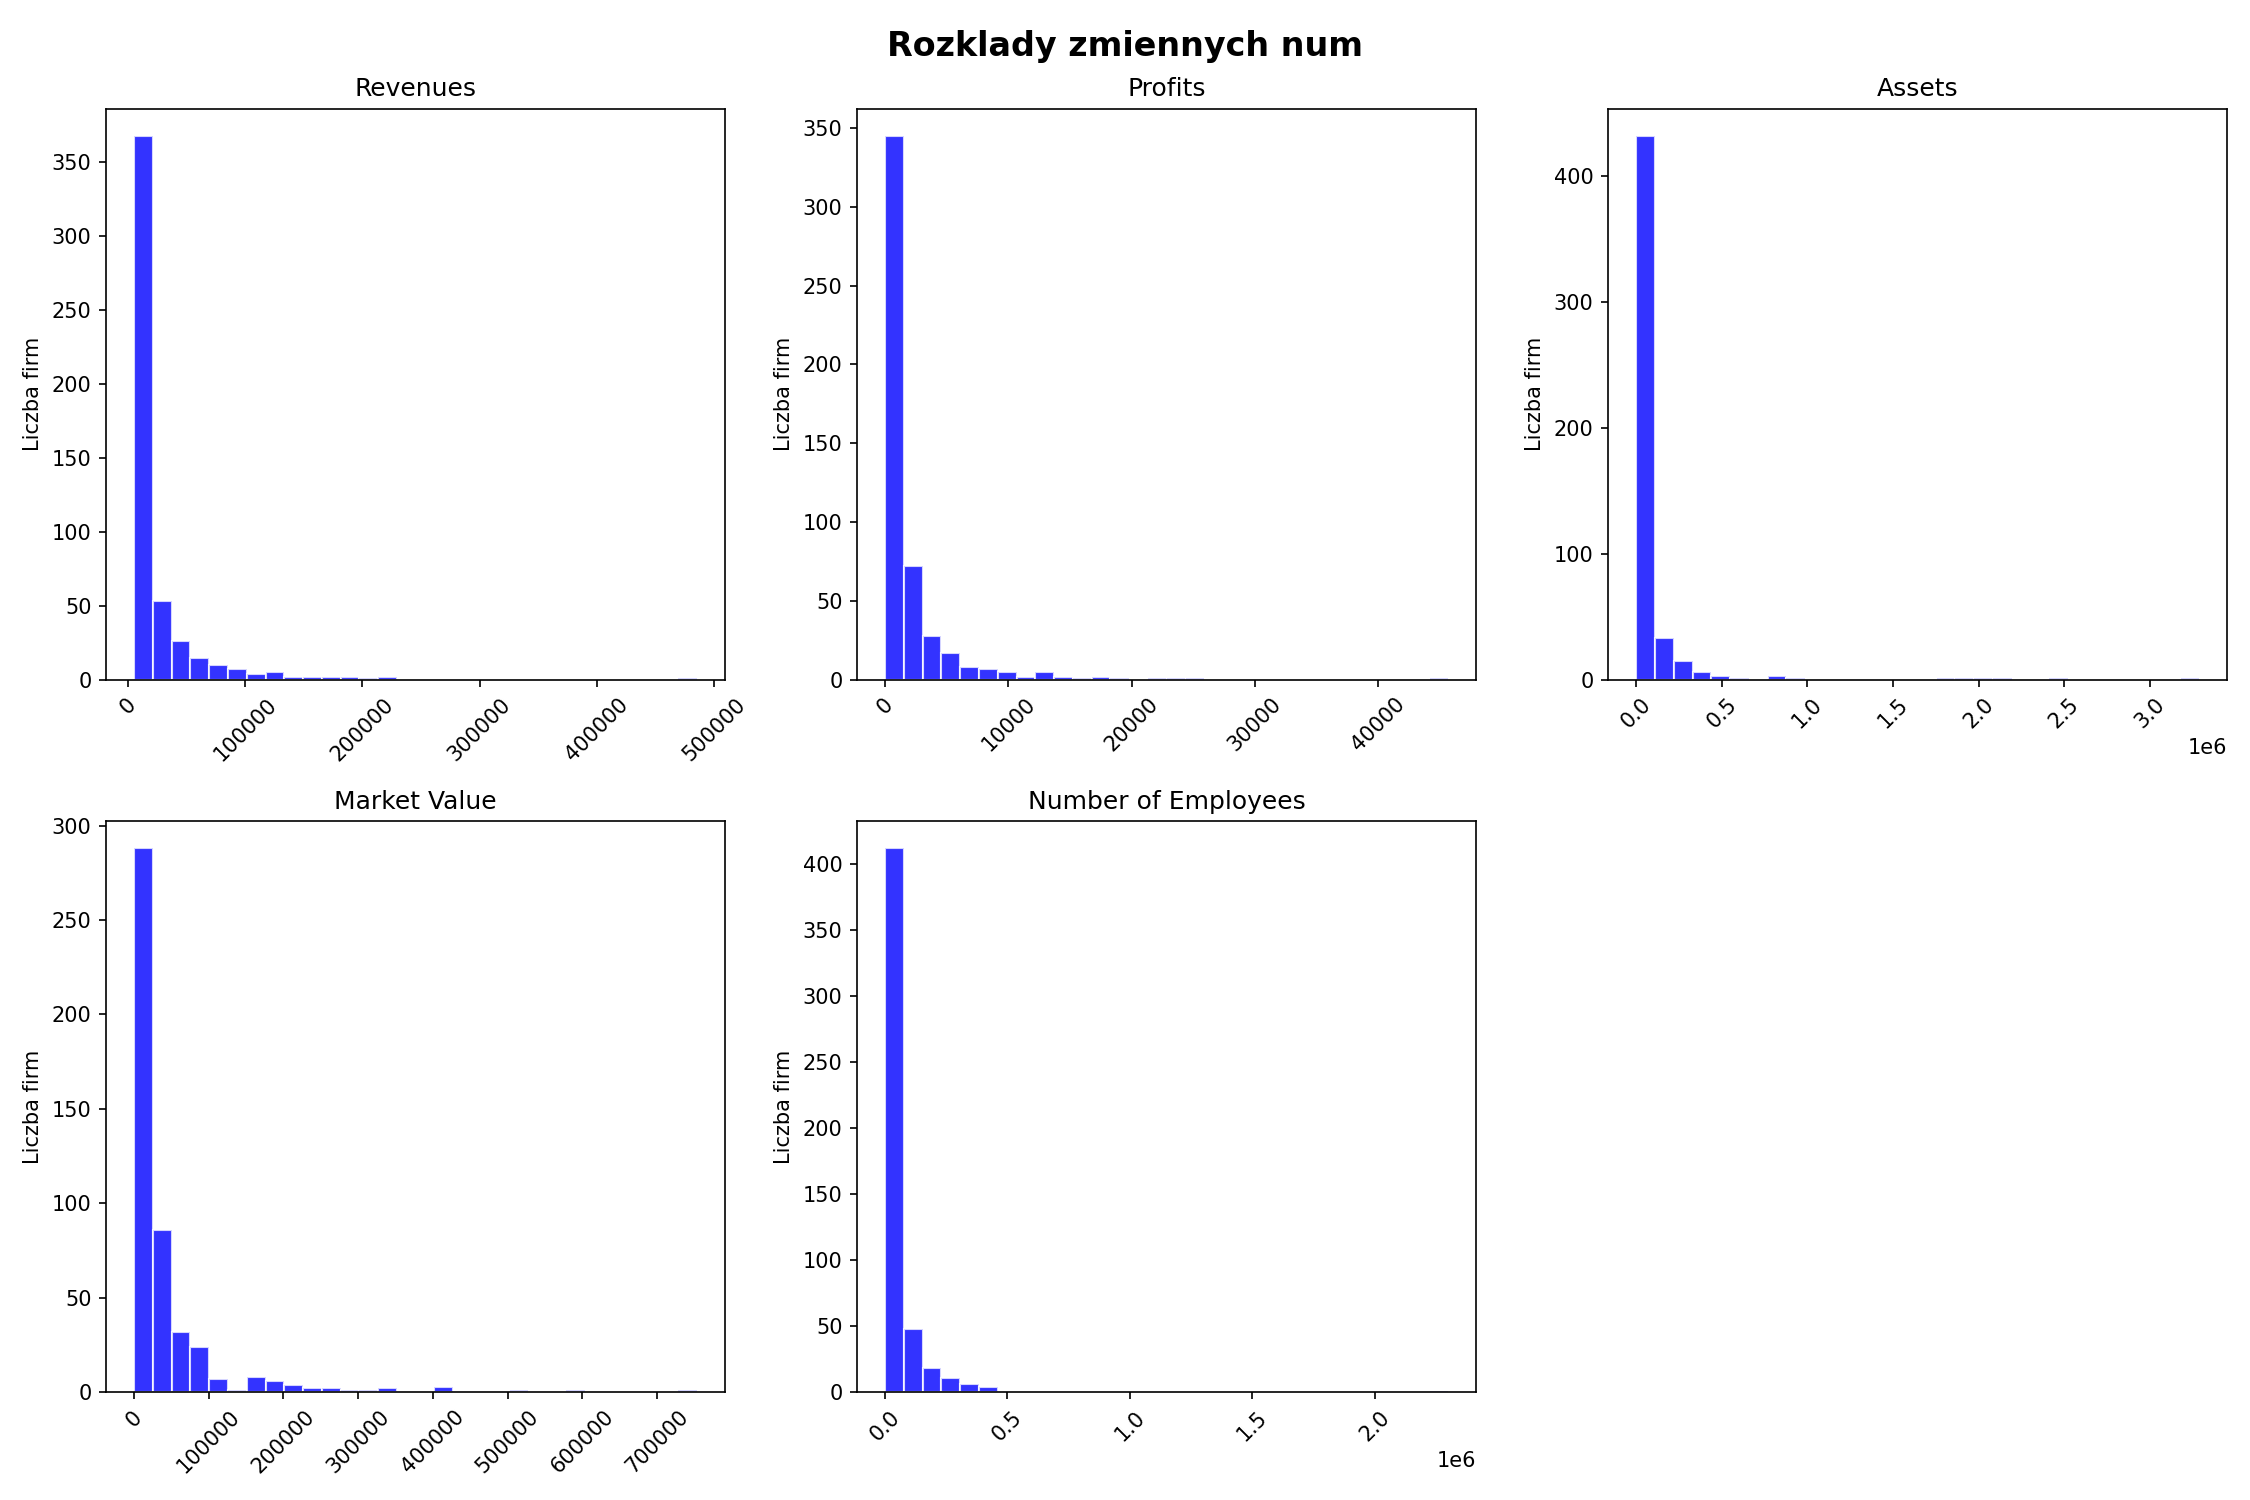

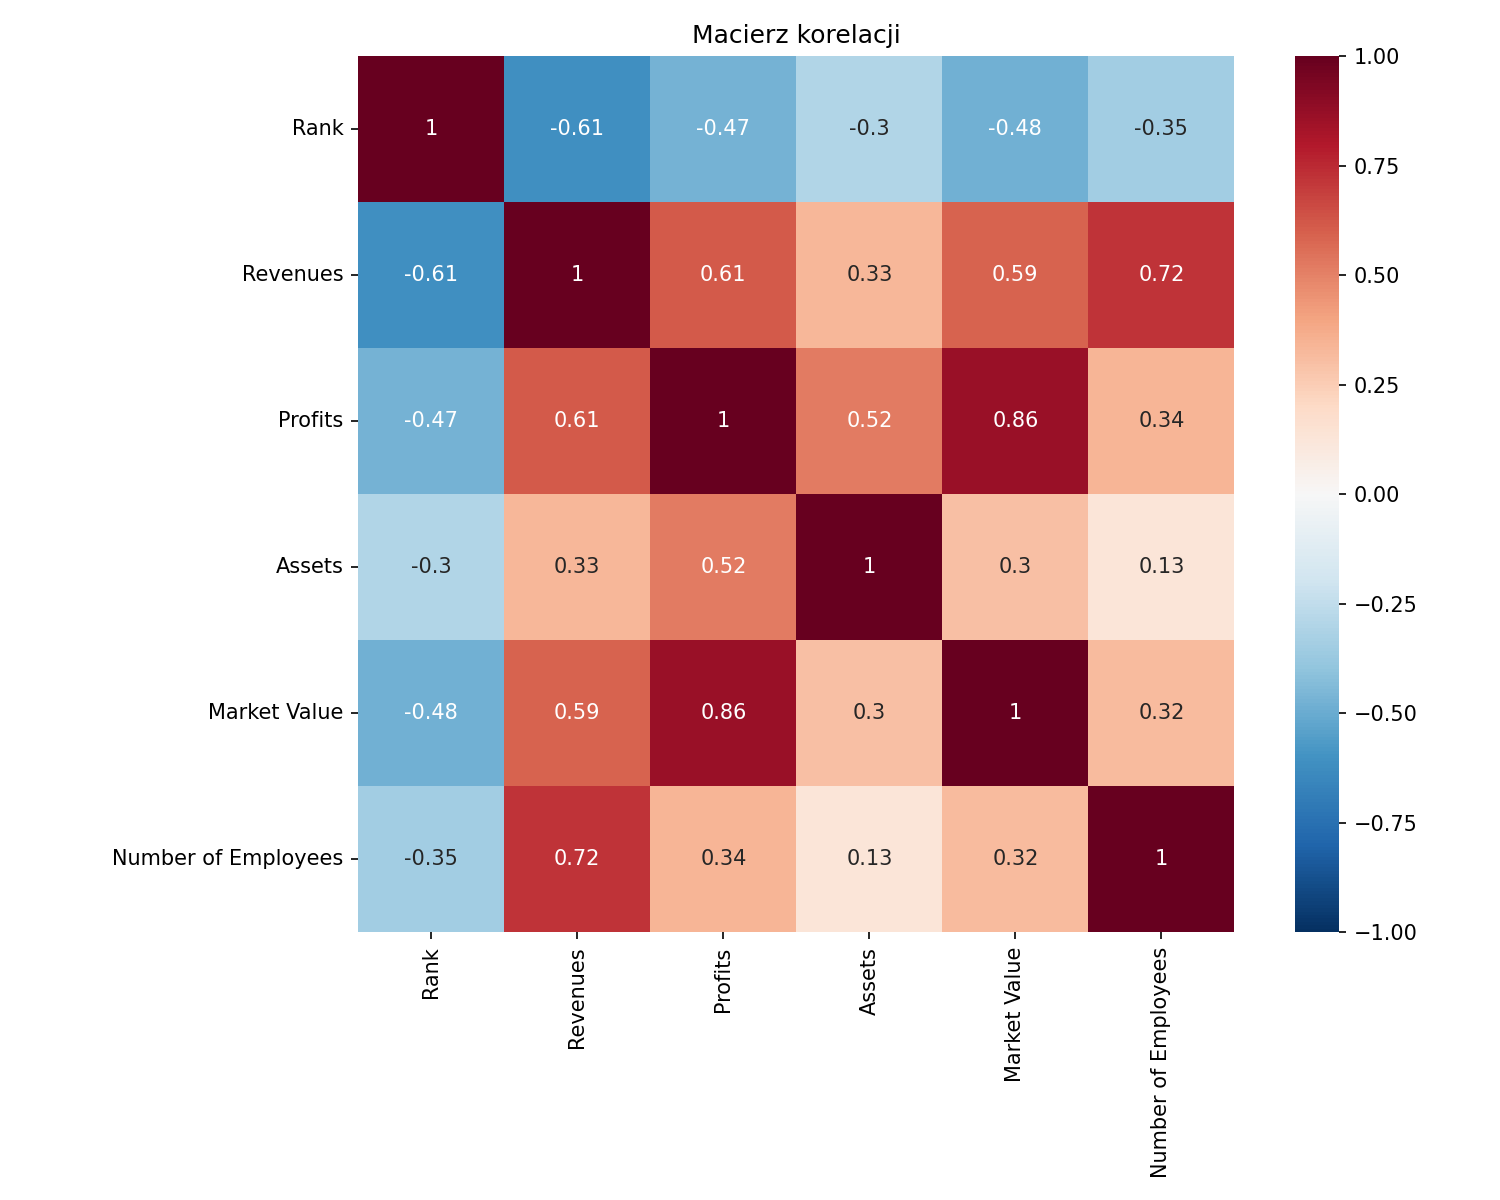

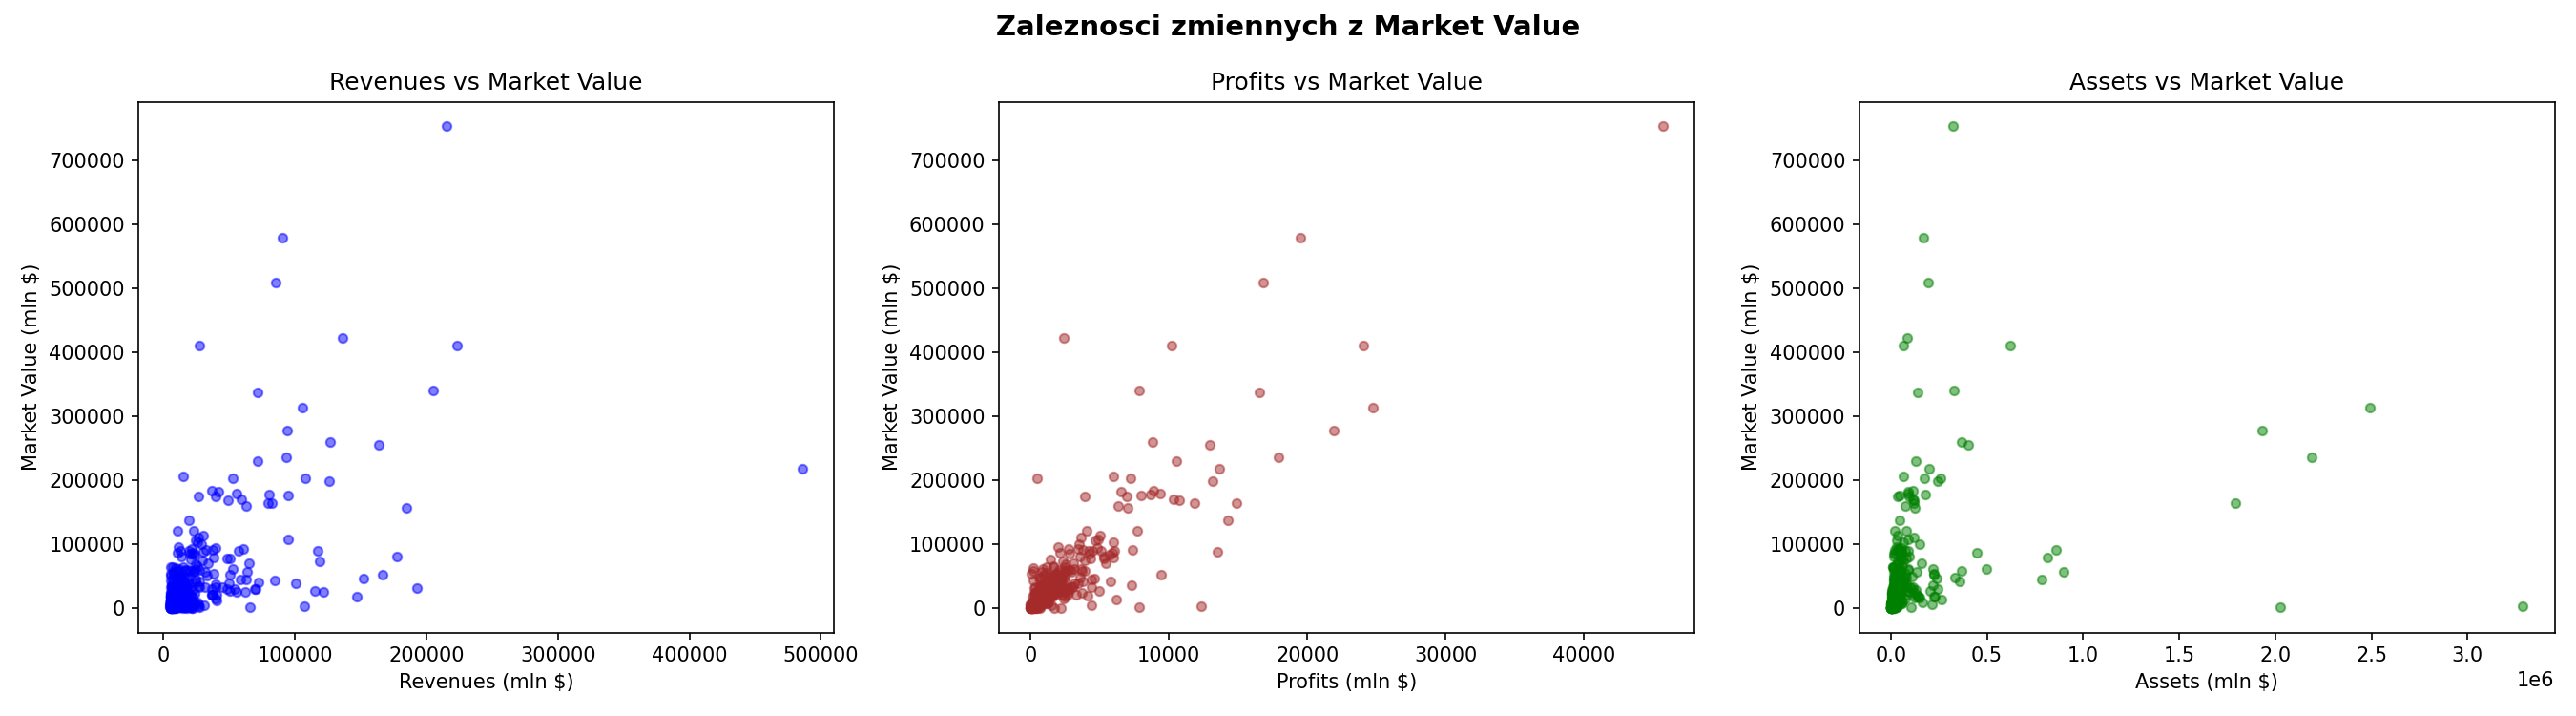

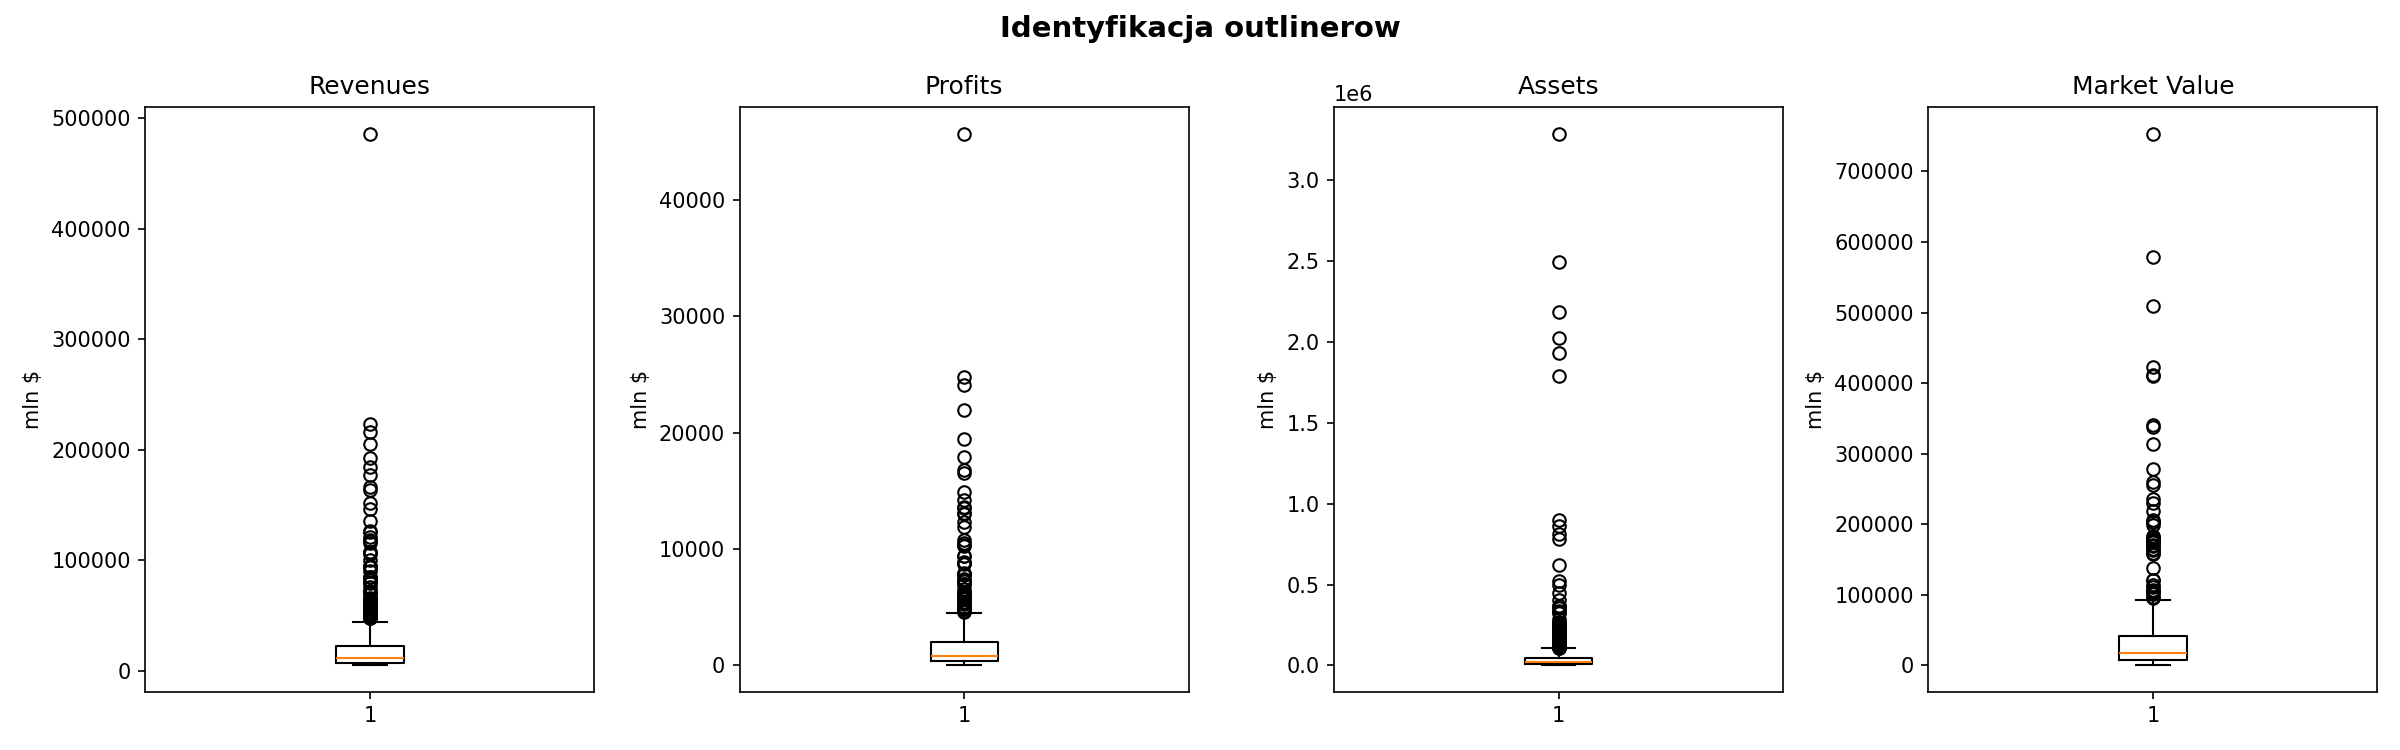

In [3]:
from IPython.display import Image, display
for fname in ["histogramy", "macierz_korelacji", "scatter_plots", "boxploty"]:
    display(Image(f"wyniki/{fname}.png"))

**Wnioski z histogramow:**
- Wszystkie zmienne finansowe maja silny skos prawy - wiekszosc firm skupiona w dolnym zakresie wartosci, najwieksze (Walmart, Apple) mocno odstaja
- Skosnosc Market Value = 4.68 - bardzo skosny rozklad, potrzerbna transformacja logarytmiczna 
- Liczba pracownikow ma ekstremalny rozklad - kilka firm zatrudnia ponad milion osob

**Wnioski ze scatter plotow:**
- Profits vs Market Value - najbardziej liniowa zaleznosc, potwierdza wynik z macierzy korelacji
- Widac outlinery: Walmart ma ogromne przychody ale wycena nie jest proporcjonalnie wysoka
- Firmy tech (Apple, Alphabet) maja wysoka wycene przy umiarkowanych przychodach
- Zaleznosc Assets vs MV jest bardzo slaba i rozproszona

**Wnioski z boxplotow:**
- Market Value ma 43 outlinery. Sa to firmy technologiczne i finansowe z bardzo wysoka wycena
- Outlinery to prawdziwe dane duzych firm, nie sa to bledy pomiarowe

## 2. Preprocessing i Feature Engineering

In [4]:
X_train, X_test, y_train, y_test, scaler, features = run_preprocessing(df)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Cechy ({len(features)}): {features}")

Dane: 500 wierszy, 10 kolumn
Nowe cechy: Profit_Margin, Revenue_Per_Employee, Asset_Turnover, Rank_Change, Log_Revenues, Log_Assets
Po usunieciu brakow: 469 wierszy
Cechy: ['Revenues', 'Profits', 'Assets', 'Number of Employees', 'Revenue Change', 'Profit_Margin', 'Revenue_Per_Employee', 'Asset_Turnover', 'Log_Revenues', 'Log_Assets']
Rozmiar: (464, 10)
Train: 371, Test: 93
Train: 371, Test: 93
Cechy (10): ['Revenues', 'Profits', 'Assets', 'Number of Employees', 'Revenue Change', 'Profit_Margin', 'Revenue_Per_Employee', 'Asset_Turnover', 'Log_Revenues', 'Log_Assets']


## 3. Modelowanie

### Modele — sciągawka

| Model | Typ | Regularyzacja | Nieliniowy? | Kiedy warto? |
|-------|-----|---------------|-------------|--------------|
| **Lin. Regression** | liniowy | brak | nie | punkt odniesienia (baseline), prosta interpretacja współczynników |
| **Lasso** | liniowy | L1 — zeruje nieistotne cechy | nie | gdy podejrzewasz, że część cech jest bezużyteczna |
| **Ridge** | liniowy | L2 — ściska współczynniki | nie | gdy wszystkie cechy są istotne, ale chcesz uniknąć overfitu |
| **Random Forest** | ensemble (bagging) | brak | **tak** | mało danych, odporność na outliery, szybki trening |
| **XGBoost** | ensemble (boosting) | wbudowana | **tak** | złożone zależności, tabular data, benchmark |
| **LightGBM** | ensemble (boosting) | wbudowana | **tak** | jak XGBoost, ale szybszy — polecany przy dużych zbiorach |

> **Bagging** (RF) — drzewa trenowane niezależnie, wynik uśredniany → redukuje wariancję  
> **Boosting** (XGB, LGBM) — każde drzewo poprawia błędy poprzedniego → redukuje obciążenie

# Metryki oceny modelu:
- MAE sredni blad bezwzgledny; kazdy blad liczy sie tak samo; latwy do interpretacji
- RMSE  karze duze bledy nieproporcjonalnie (przez kwadrat); wrazliwy na wartosci odstajace
- R2  ile wariancji zmiennej docelowej wyjasnia model (0 = bezuzyteczny, 1 = idealny)
- Uzywamy wszystkich trzech bo razem daja pelniejszy obraz jakosci modelu

In [5]:
results, models, predictions = run_modelling(X_train, X_test, y_train, y_test)

Lin. Regression      MAE:     21,077  RMSE:     47,955  R2: 0.5717
Lasso                MAE:     21,074  RMSE:     47,952  R2: 0.5717
Random Forest        MAE:     19,965  RMSE:     51,169  R2: 0.5123
XGBoost              MAE:     23,034  RMSE:     53,927  R2: 0.4583
Ridge                MAE:     20,928  RMSE:     47,704  R2: 0.5761
LightGBM             MAE:     23,427  RMSE:     54,387  R2: 0.4491

Najlepszy: Ridge (R2=0.5761)
  Lin. Regression: max blad = 365,369 mln $
  Lasso: max blad = 365,363 mln $
  Random Forest: max blad = 367,807 mln $
  XGBoost: max blad = 363,817 mln $
  Ridge: max blad = 364,062 mln $
  LightGBM: max blad = 355,305 mln $


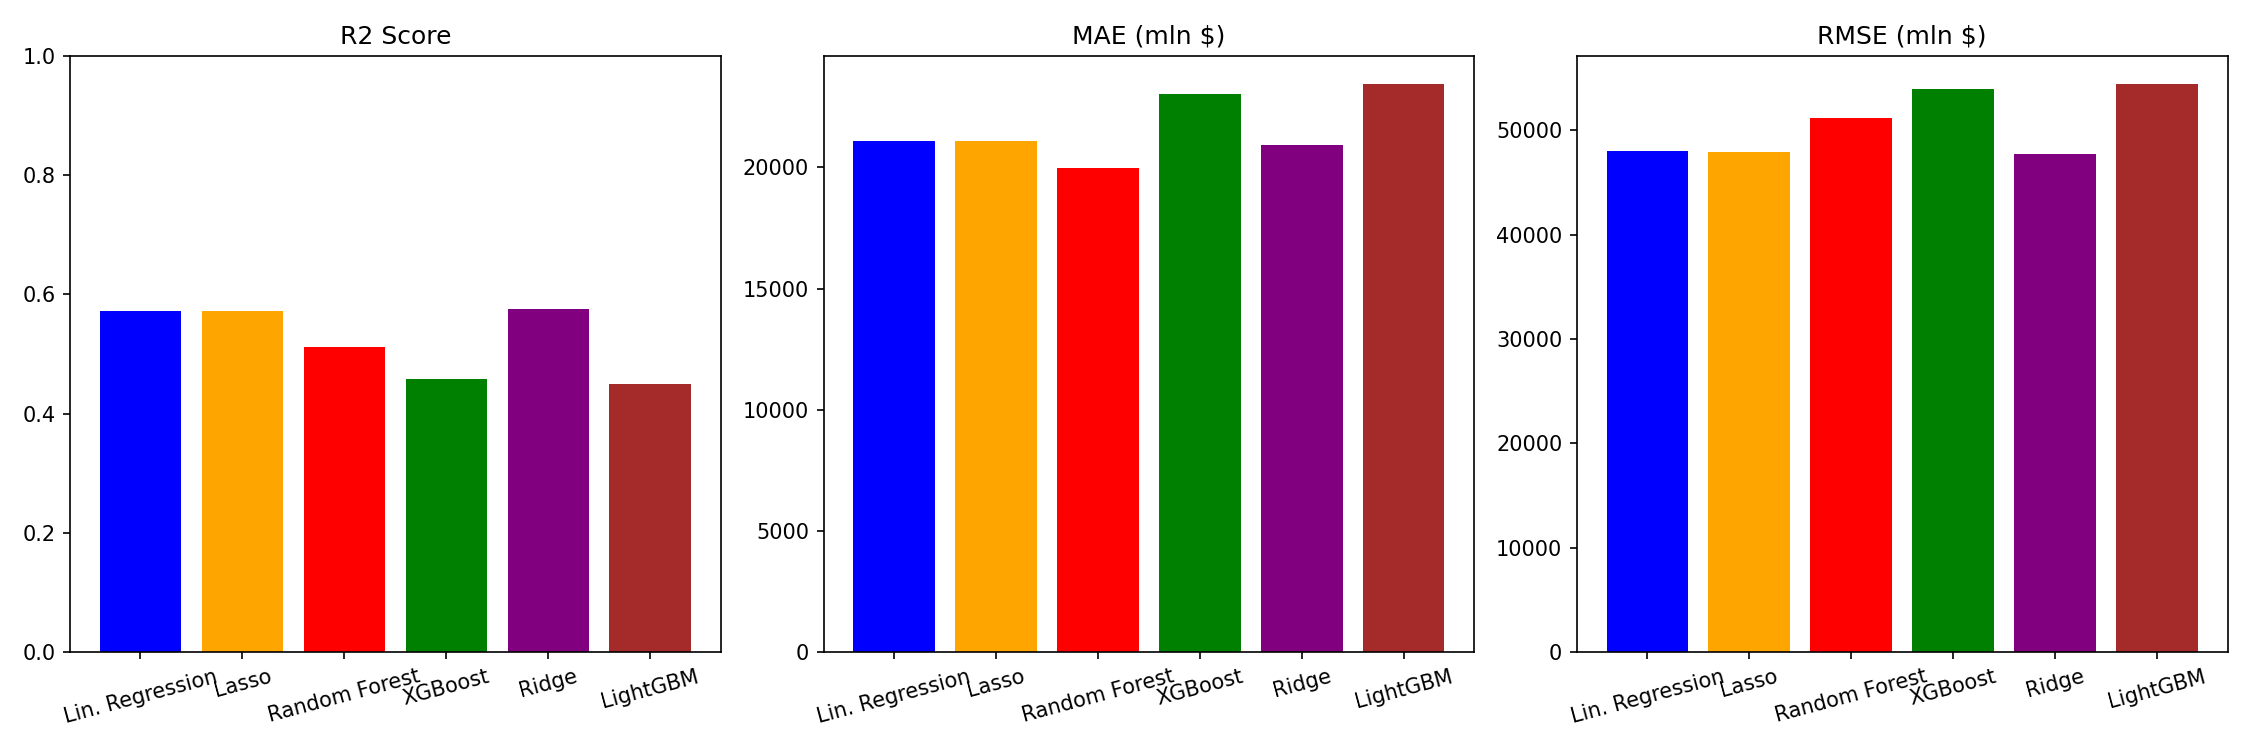

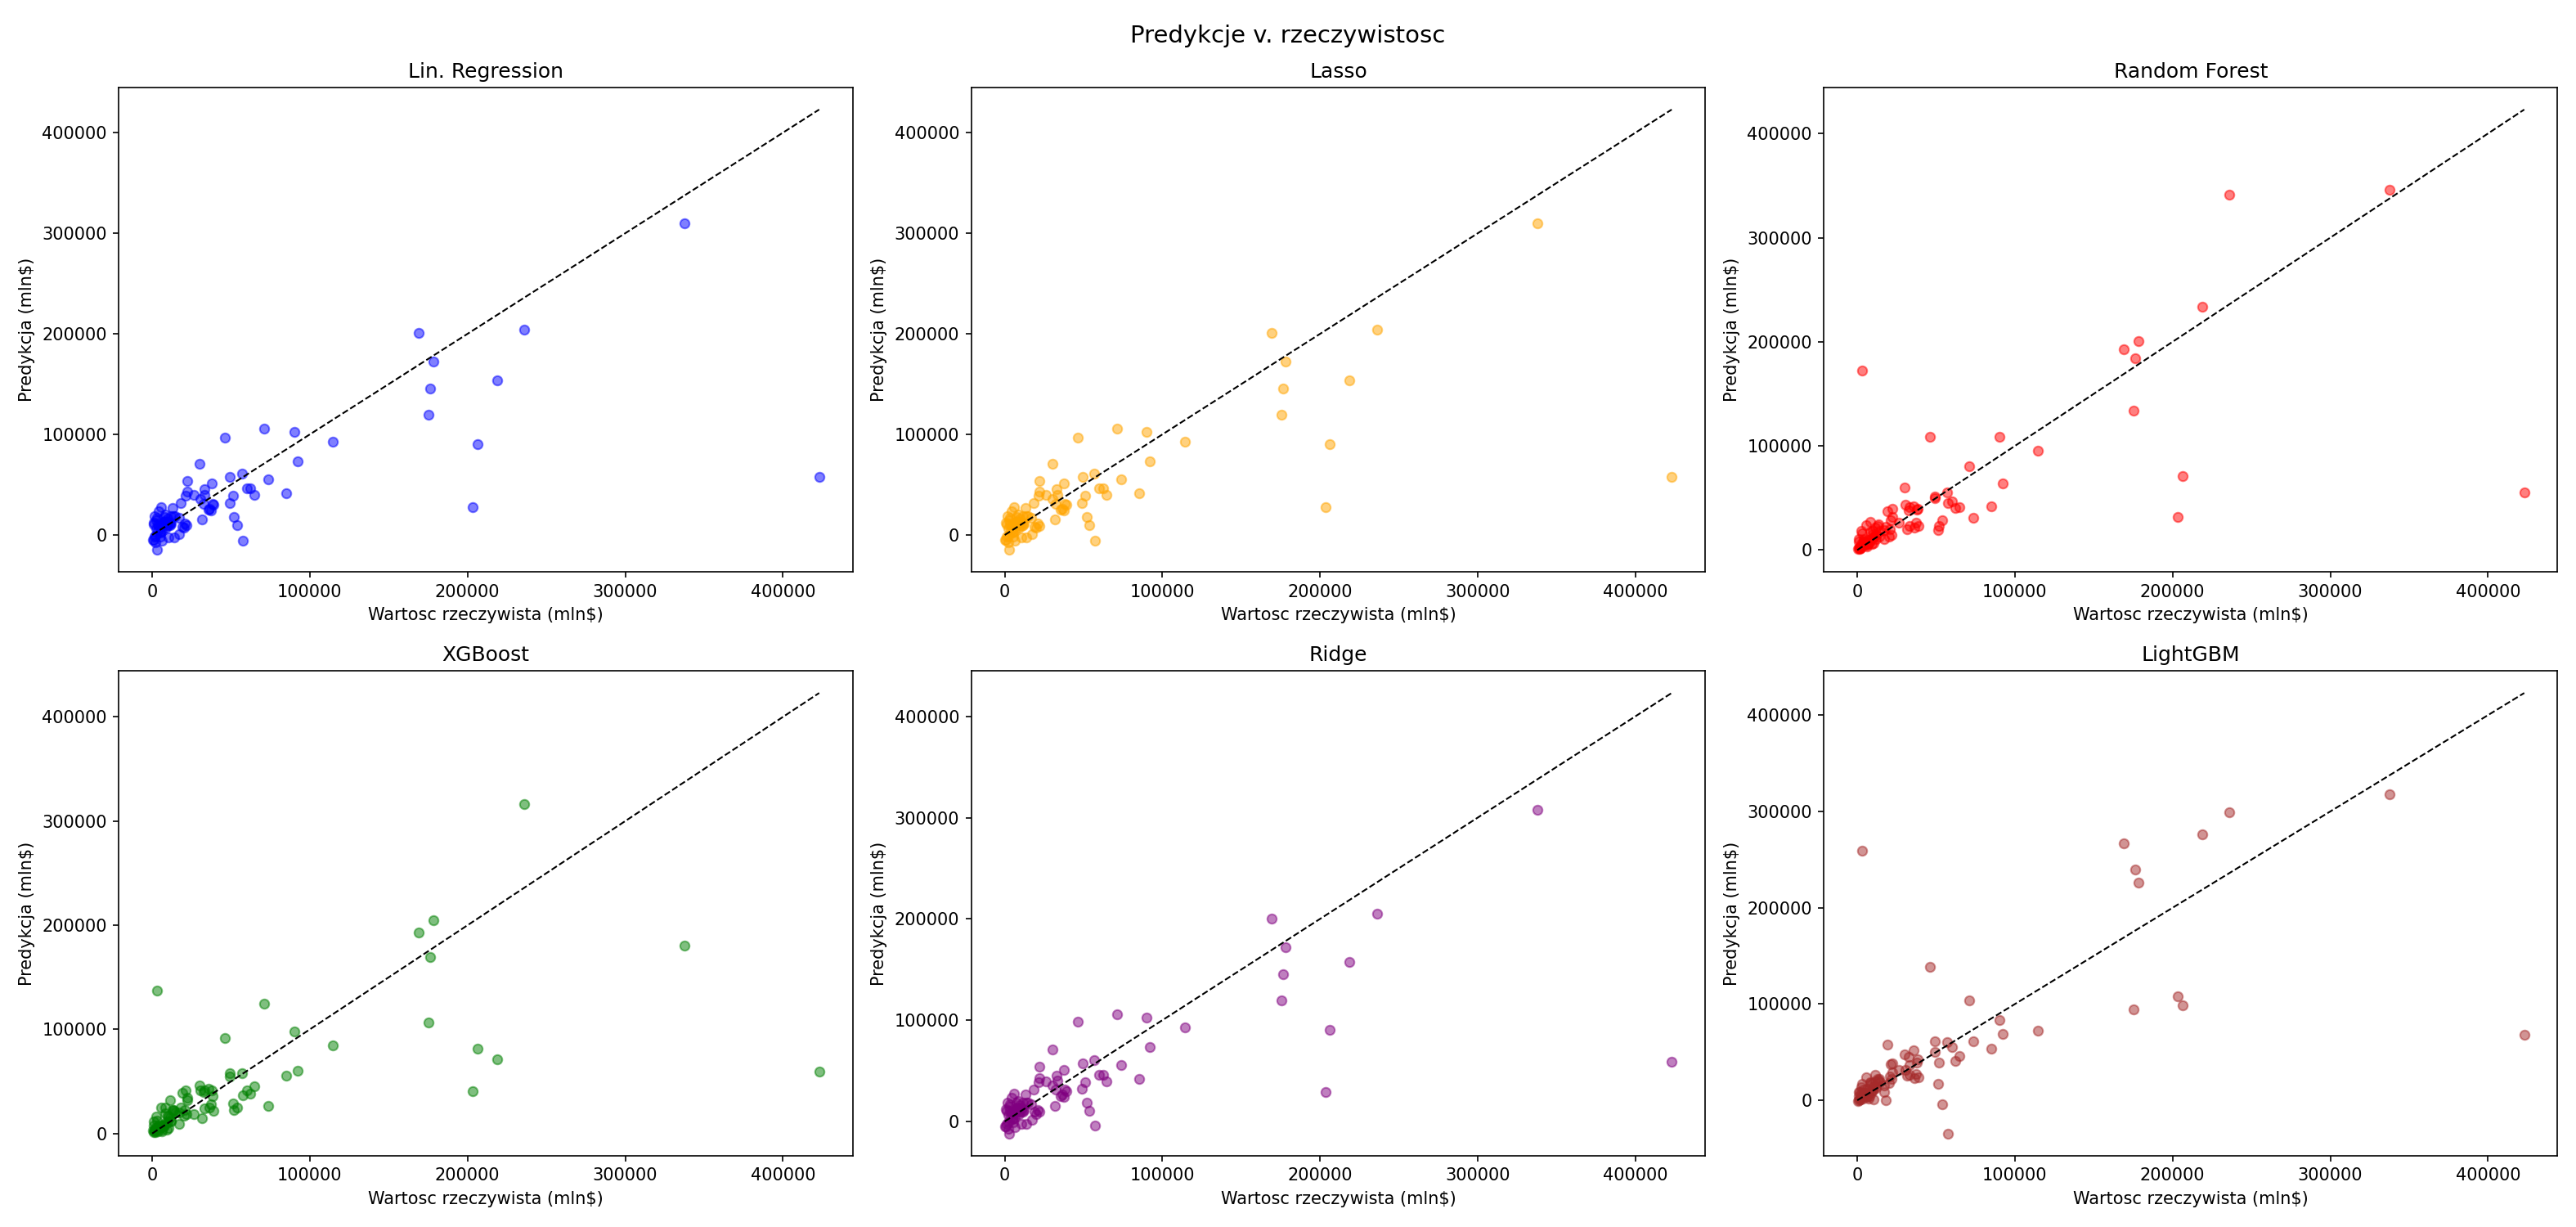

In [6]:
from IPython.display import Image, display
for fname in ["porownanie_modeli", "predykcje_vs_rzeczywiste"]:
    display(Image(f"wyniki/{fname}.png"))

**Wnioski z modelowania:**
- Linear Regression daje najwyzsze R2 na zbiorze testowym- przy malej ilosci danych (464 prob) prostszy model moze generalizowac lepiej
- Wszystkie modele maja duzy max blad (ok. 365 tys mln $) - dotycza firm tech z wysoka premia rynkowa, ktorych wartosc trudno przewidziec z samych danych fin.
- Punkty blisko linii przerywanej = dobre predykcje, duze odchylenia = firmy trudne do wyceny
- R2 okolo 0.5 oznacza ze model wyjasnia ok. 50% zmiennosci Market Value - reszta to czynniki nieuwzglednione w danych (marka, innowacje, oczekiwania rynku)

## 4. Optymalizacja hiperparametrow

In [7]:
best_model, best_name, results_opt, study_rf, study_xgb, study_lasso, study_ridge, study_lgbm = run_optimization(
    X_train, X_test, y_train, y_test, results, n_trials=30
)

Optymalizacja Random Forest (30 trials)...
Najlepsze parametry RF: {'n_estimators': 199, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 2}
R2 (CV): 0.7368

Optymalizacja XGBoost (30 trials)...
Najlepsze parametry XGB: {'n_estimators': 203, 'max_depth': 4, 'learning_rate': 0.0870508592819846, 'subsample': 0.8122660508861638, 'colsample_bytree': 0.7731153684199995}
R2 (CV): 0.7766

Optymalizacja Lasso (30 trials)...
Najlepsze parametry Lasso: {'alpha': 99.75680427493488}
R2 (CV): 0.7805

Optymalizacja Ridge (30 trials)...
Najlepsze parametry Ridge: {'alpha': 12.302916705865552}
R2 (CV): 0.7946

Optymalizacja LightGBM (30 trials)...
Najlepsze parametry LightGBM: {'n_estimators': 168, 'max_depth': 3, 'learning_rate': 0.09559824438329322, 'num_leaves': 40}
R2 (CV): 0.6856

Po optymalizacji:
Random Forest (opt)  MAE:     19,780  RMSE:     51,662  R2: 0.5029
XGBoost (opt)        MAE:     20,350  RMSE:     48,253  R2: 0.5663
Lasso (opt)          MAE:     20,735  RMSE:     47,673  

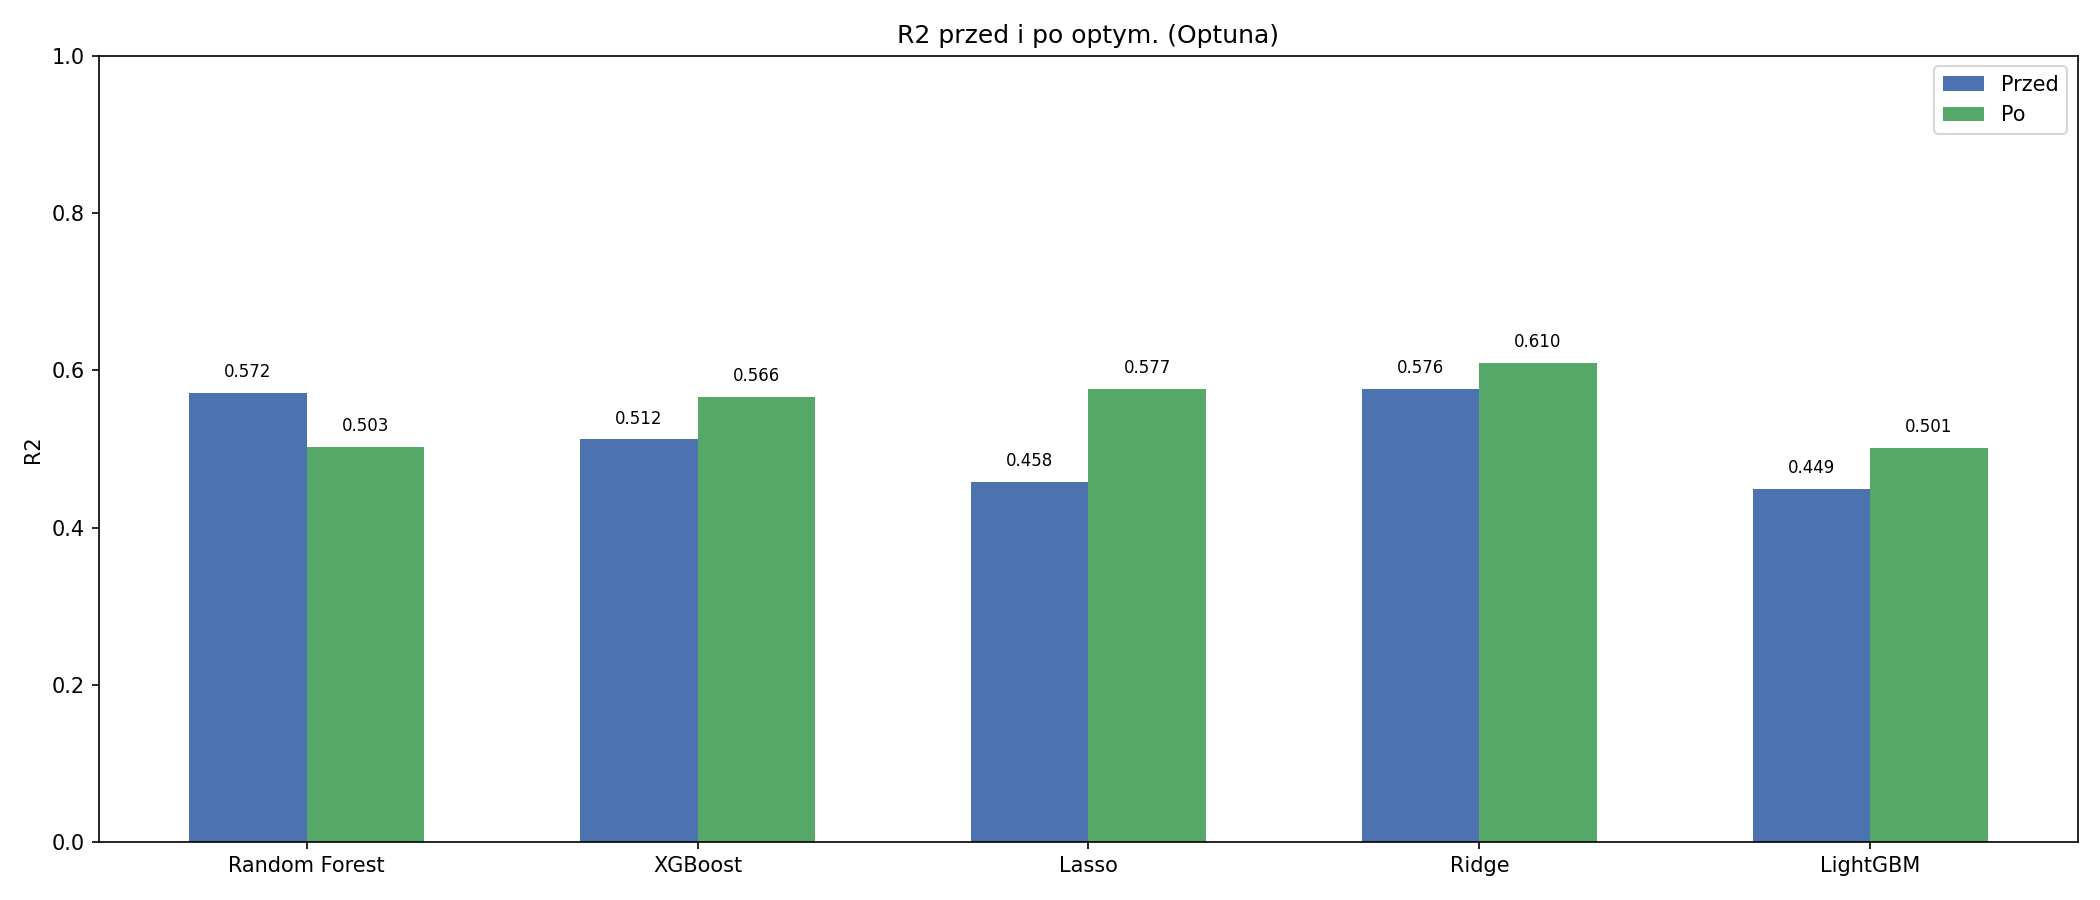

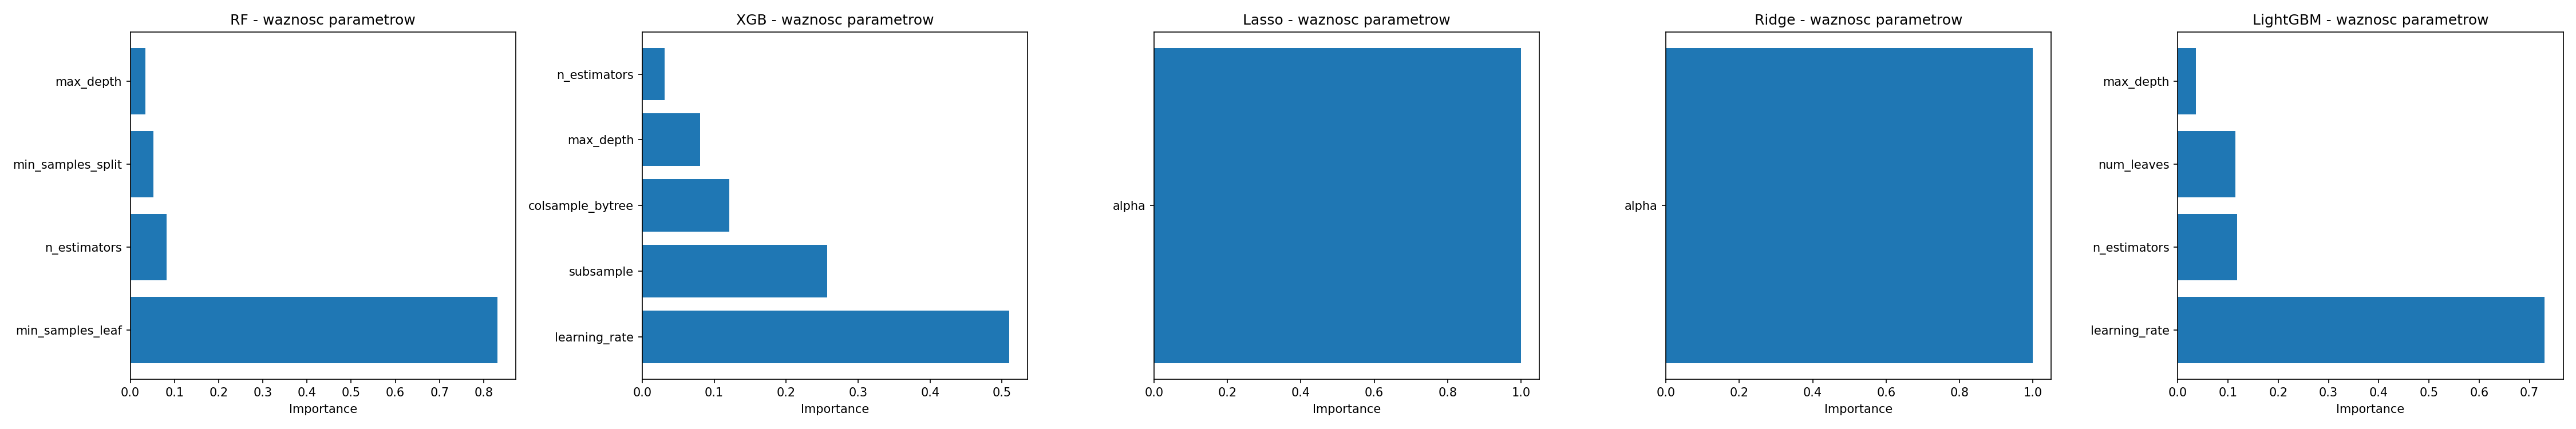

In [8]:
from IPython.display import Image, display
for fname in ["optymalizacja_porownanie", "optuna_parametry"]:
    display(Image(f"wyniki/{fname}.png"))

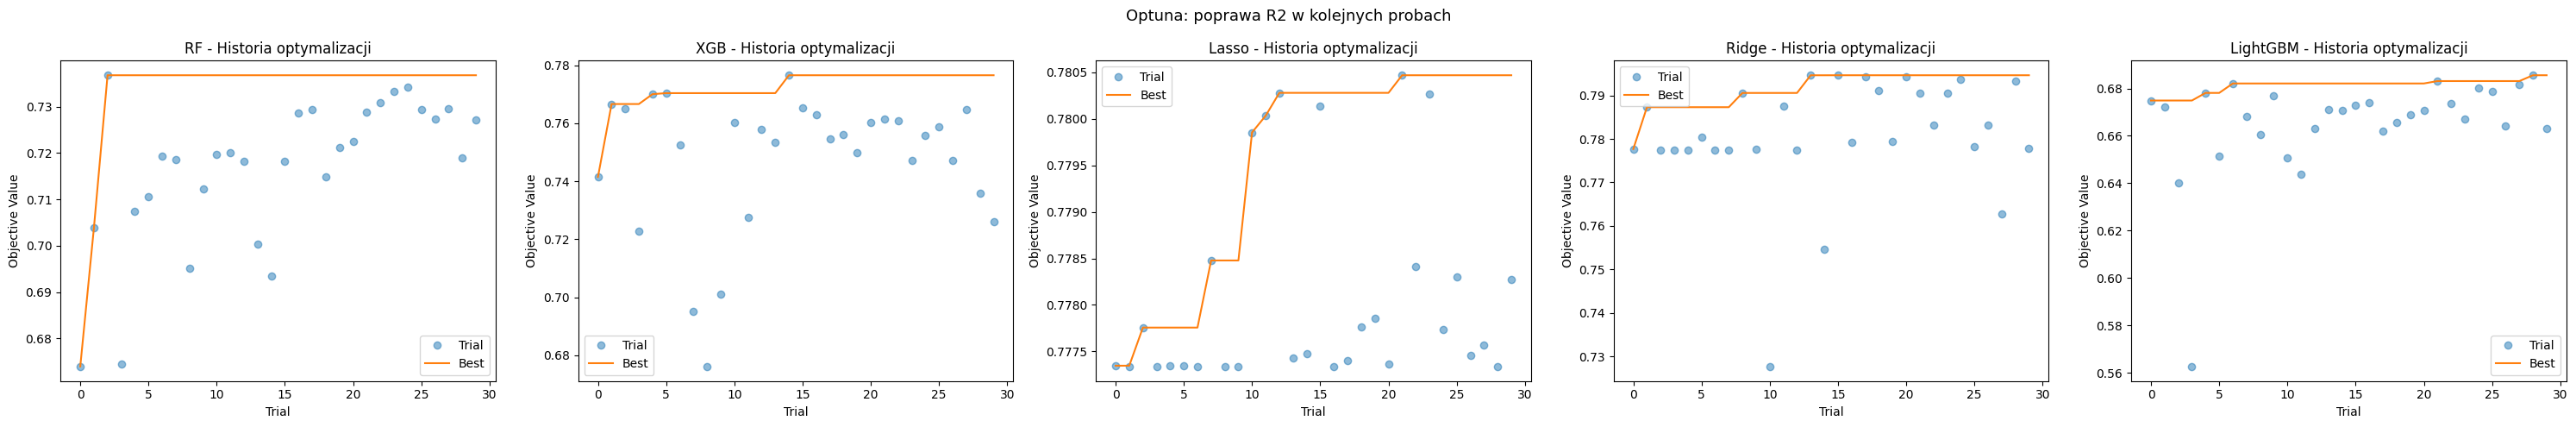

In [9]:
from src.modelling.optimization import _plot_history

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
_plot_history(study_rf,    axes[0], "RF - Historia optymalizacji")
_plot_history(study_xgb,   axes[1], "XGB - Historia optymalizacji")
_plot_history(study_lasso, axes[2], "Lasso - Historia optymalizacji")
_plot_history(study_ridge, axes[3], "Ridge - Historia optymalizacji")
_plot_history(study_lgbm,  axes[4], "LightGBM - Historia optymalizacji")
plt.suptitle("Optuna: poprawa R2 w kolejnych probach", fontsize=13)
plt.tight_layout()
plt.show()

**Wnioski z optymalizacji (Optuna):**
- Optuna uzywa algorytmu TPE (Tree-structured Parzen Estimator) - w odroznieniu od GridSearchCV nie przeszukuje siatki, ale buduje model probabilistyczny i kieruje kolejne proby w obszary o wyzszym R2
- Przestrzen przeszukiwan jest szersza i ciagla: np. `learning_rate` probkowane logarytmicznie miedzy 0.01 a 0.3 zamiast 3 z gory ustalonych wartosci
- 30 prob Optuna vs 36 kombinacji GridSearch dla RF - podobna liczba fitow, ale Optuna pokrywa wiekszy obszar i adaptatywnie skupia sie na obiecujacych regionach
- `optuna.logging.set_verbosity(WARNING)` wycisza verbose output; mozna uzyc `optuna.visualization` do wykresu historii optymalizacji

## 4b. GridSearchCV — porównanie z Optuna

In [10]:
from src.modelling.optimization import run_gridsearch

results_gs = run_gridsearch(X_train, X_test, y_train, y_test, results_opt)

GridSearchCV (cv=5):
Random Forest (GS)   MAE:     20,095  RMSE:     51,125  R2: 0.5132
  Random Forest: 90 fits, best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
XGBoost (GS)         MAE:     20,403  RMSE:     50,525  R2: 0.5245
  XGBoost: 135 fits, best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Lasso (GS)           MAE:     20,734  RMSE:     47,672  R2: 0.5767
  Lasso: 30 fits, best params: {'alpha': 100.0}
Ridge (GS)           MAE:     19,975  RMSE:     46,064  R2: 0.6048
  Ridge: 30 fits, best params: {'alpha': 10.0}
LightGBM (GS)        MAE:     23,001  RMSE:     51,172  R2: 0.5123
  LightGBM: 135 fits, best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


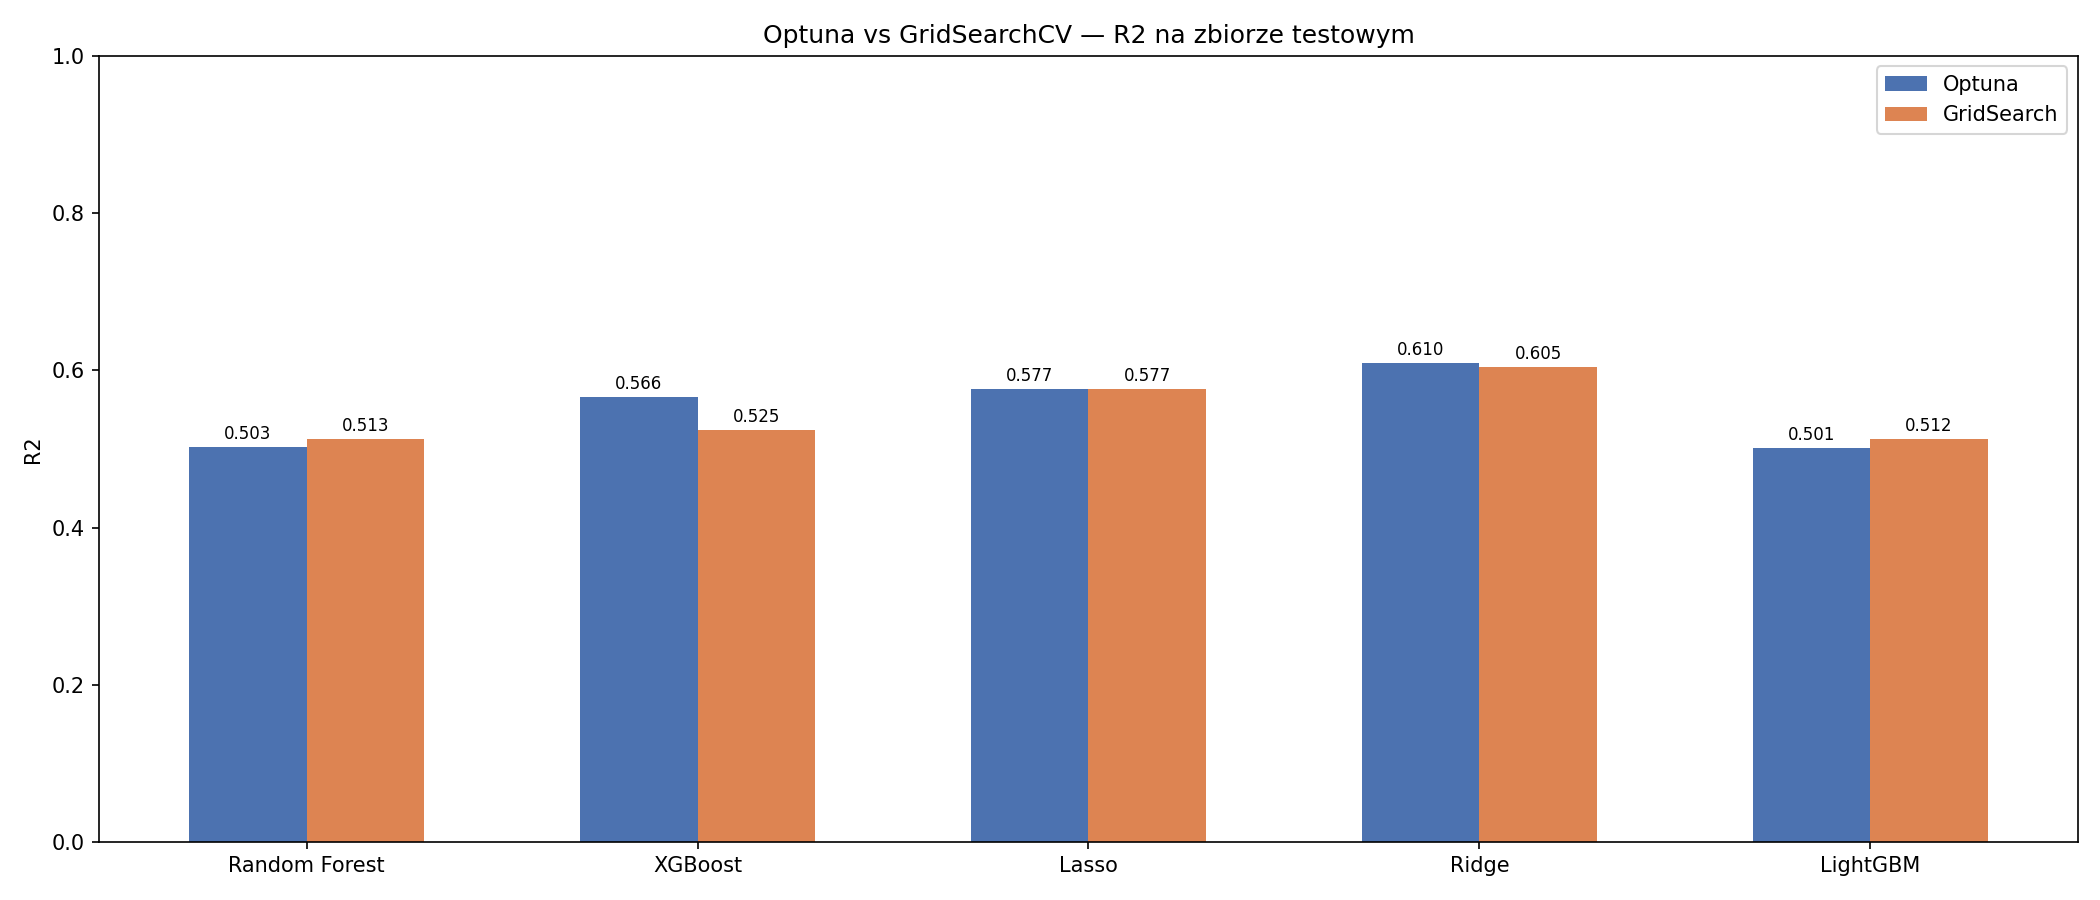

In [11]:
display(Image("wyniki/gridsearch_vs_optuna.png"))

**Optuna vs GridSearchCV:**
- GridSearch przeszukuje z góry ustaloną siatkę wyczerpująco — gwarantuje najlepszą kombinację *w tej siatce*
- Optuna nie jest związana siatką — może trafić na wartości pośrednie (np. alpha=5.31 zamiast 1.0 lub 10.0)
- Przy modelach liniowych (Ridge, Lasso) wyniki są podobne; przy ensemble różnica może być większa gdy Optuna ma więcej swobody w ciągłej przestrzeni

## 5. Interpretacja wynikow

In [12]:
importance = run_interpretation(best_model, X_test, features)

Ranking cech:
  Profits                   69121.2117
  Assets                    13558.8721
  Log_Assets                7907.2502
  Profit_Margin             7872.8842
  Revenue_Per_Employee      5004.4498
  Revenues                  4812.6431
  Revenue Change            4419.7837
  Number of Employees       3925.7579
  Log_Revenues              3110.6555
  Asset_Turnover            1656.9338

Najwazniejsza cecha: Profits (69121.2117)

Obliczanie SHAP...
Najwazniejsza cecha wg SHAP: Profits (sredni |SHAP| = 35731)

PDP dla: ['Profits', 'Assets', 'Log_Assets', 'Profit_Margin']

Wykresy zapisane w wyniki/


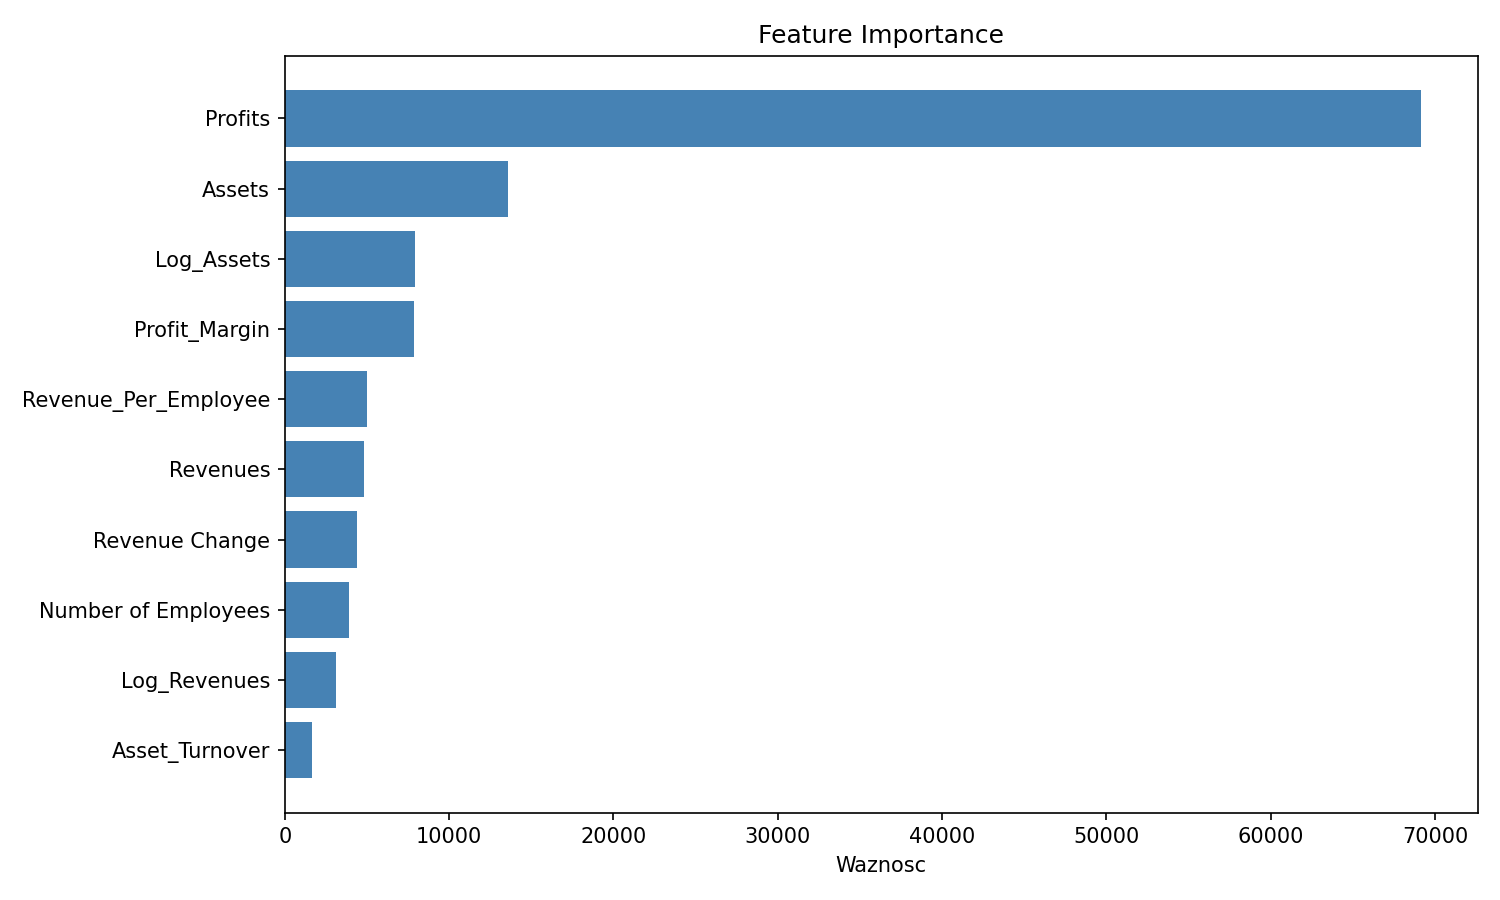

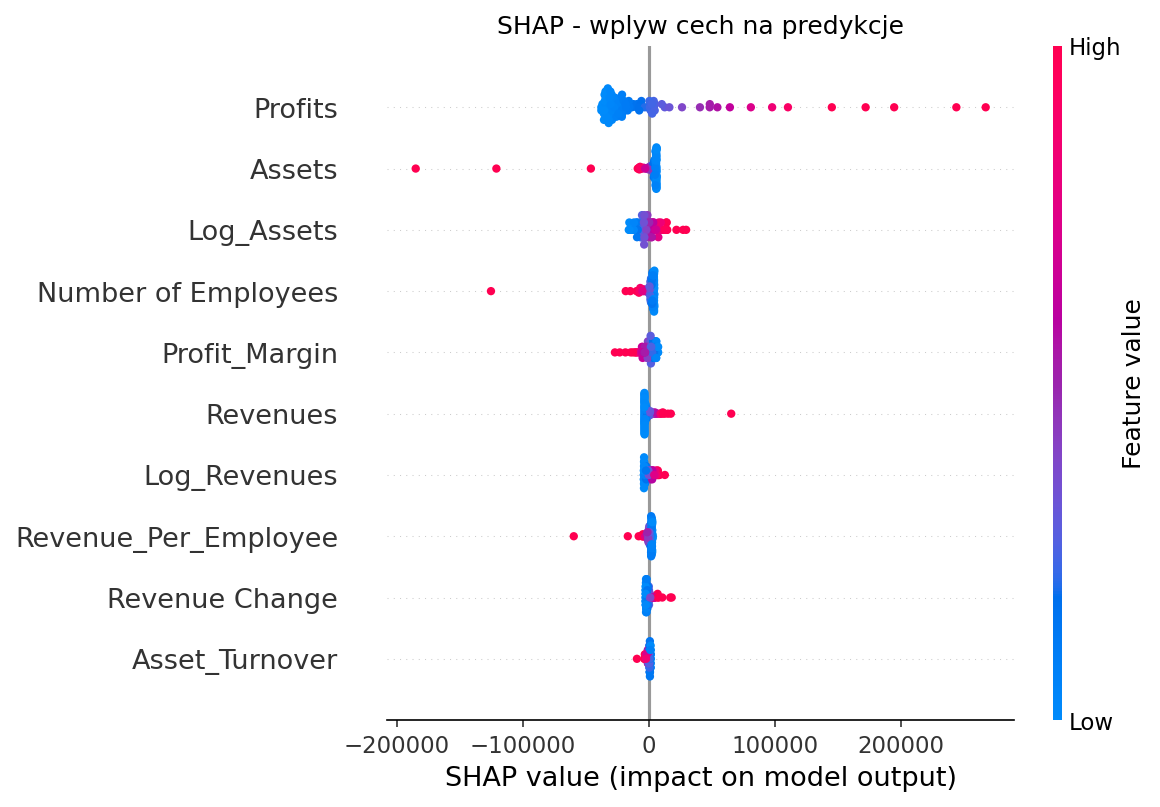

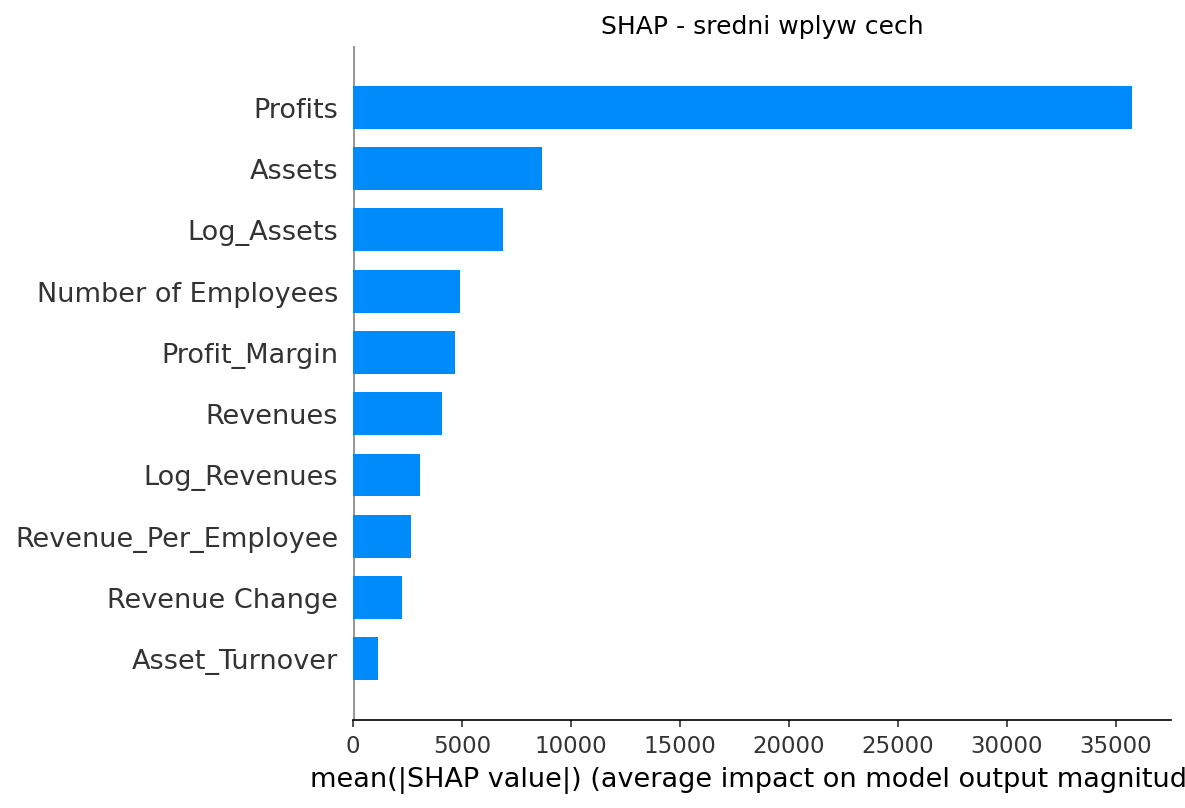

In [13]:
from IPython.display import Image, display
for fname in ["feature_importance", "shap_summary", "shap_bar"]:
    display(Image(f"wyniki/{fname}.png"))

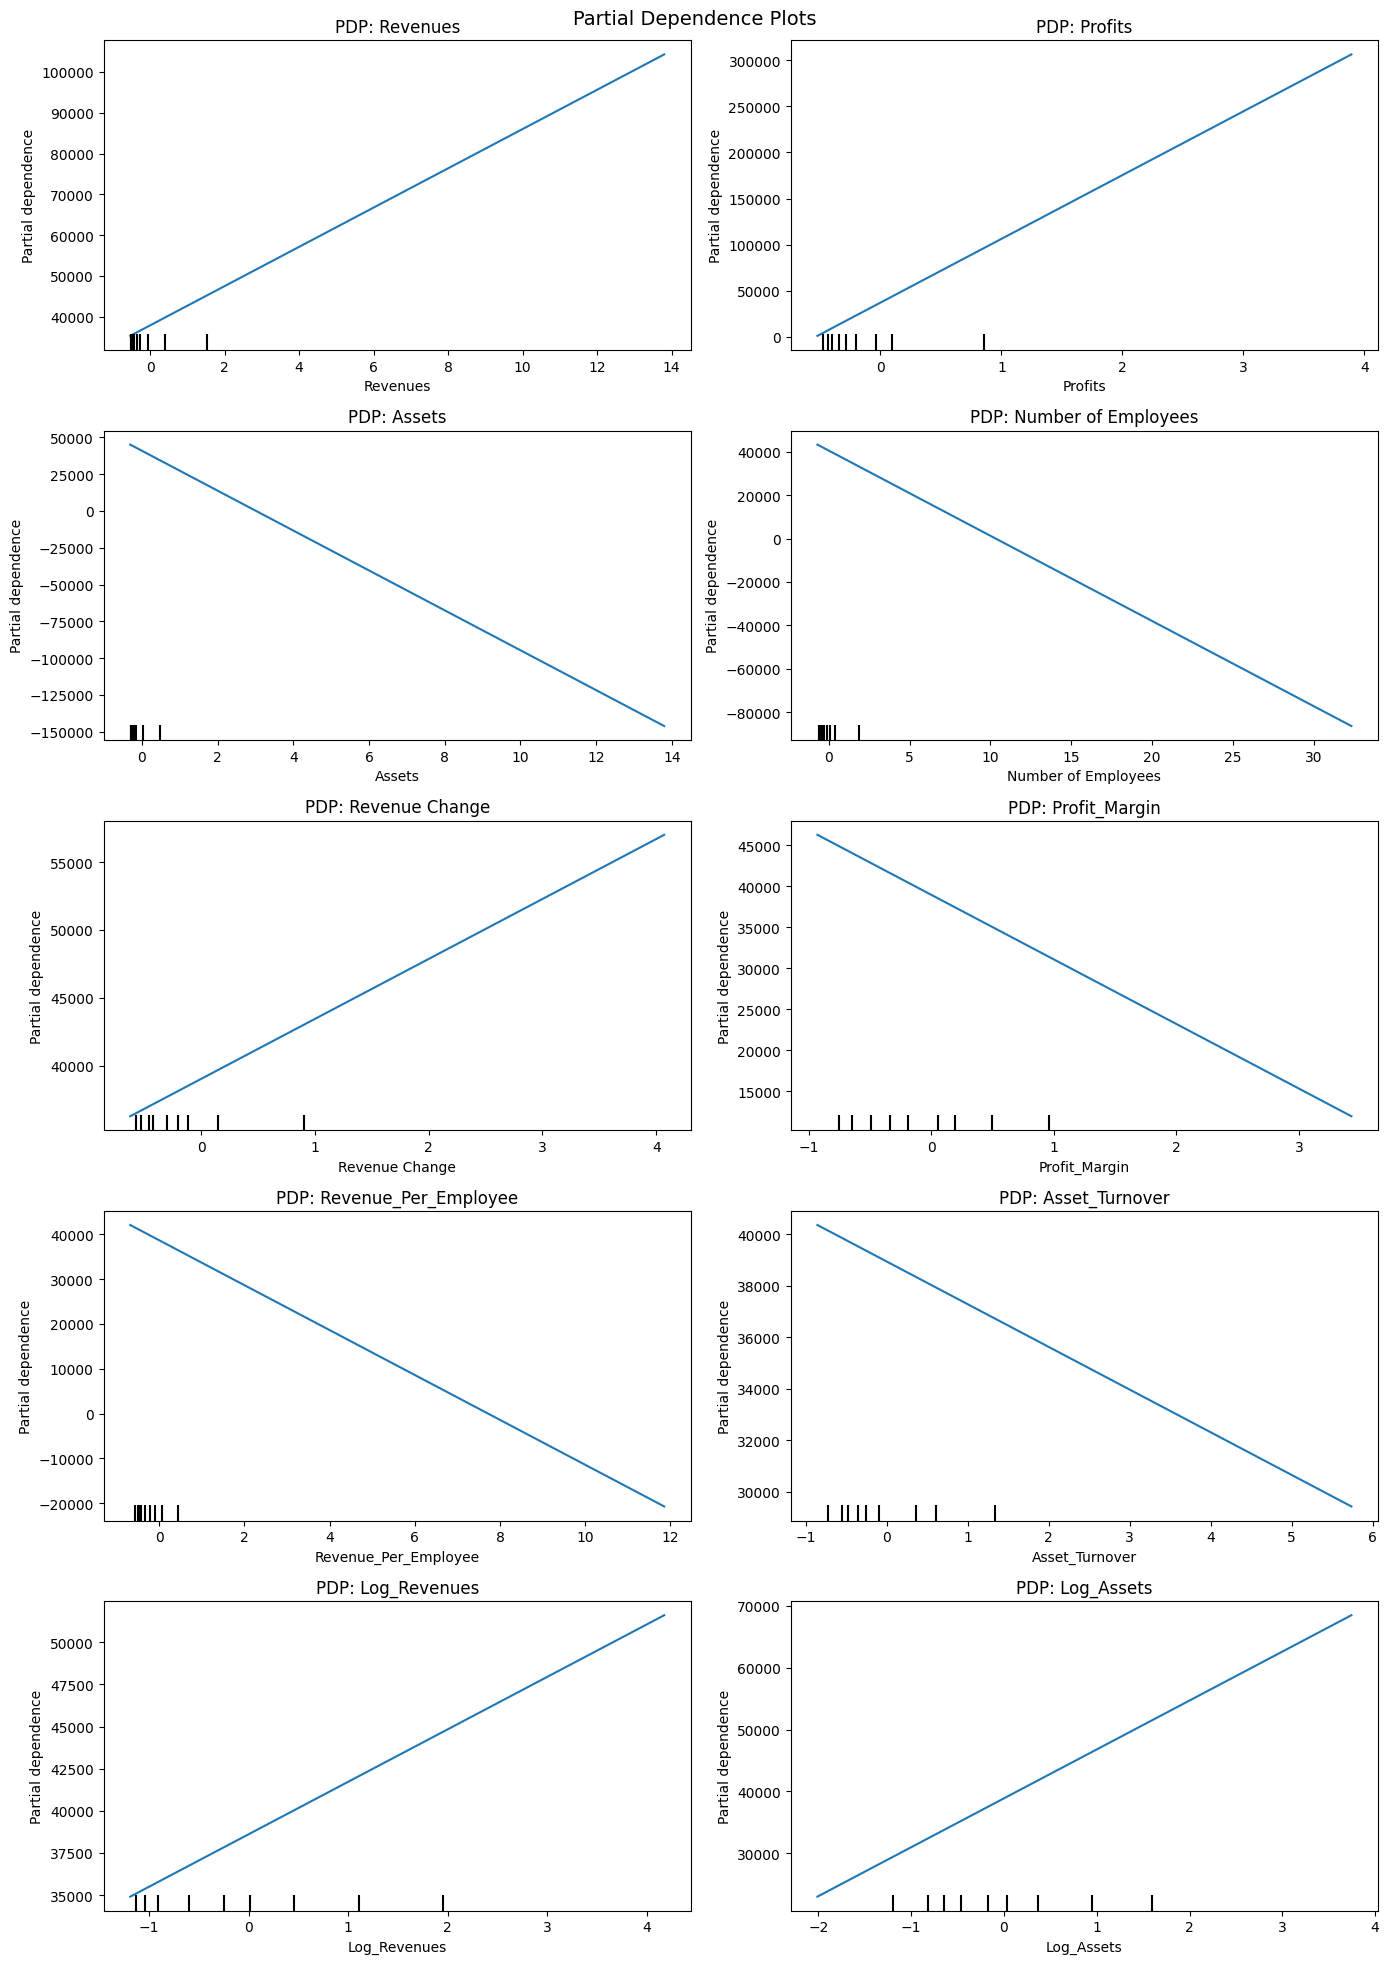

In [14]:
import math
from sklearn.inspection import PartialDependenceDisplay

# PDP dla wszystkich cech
n = len(features)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
ax_list = axes.flatten()

for i, feat in enumerate(features):
    idx = features.index(feat)
    PartialDependenceDisplay.from_estimator(
        best_model, X_test, features=[idx],
        feature_names=features, ax=ax_list[i], kind="average"
    )
    ax_list[i].set_title(f"PDP: {feat}")

for j in range(n, len(ax_list)):
    ax_list[j].set_visible(False)

plt.suptitle("Partial Dependence Plots", fontsize=14)
plt.tight_layout()
plt.savefig("wyniki/pdp_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Wnioski z Feature Importance:**
- Profits zdecydowanie dominuje (~73% waznosci)- zyski sa najwazniejszym czynnikiem predykcji wartosci rynkowej
- Number of Employees na drugim miejscu, czyli  wielkosc firmy ma znaczenie
- Revenue Change (dynamika wzrostu) tez istotne- rynek wycenia firmy rosnace wyzej
- Log_Revenues i Log_Assets maja zerowa waznosc - model juz korzysta z oryginalnych wartosci, transformacje log nie daja dodatkowej informacji


**Wnioski z analizy SHAP:**
- SHAP potwierdza dominacje Profits- wysokie zyski (czerwone punkty po prawej) zdecydowanie podnoszaja predykcje Market Value
- W odroznieniu od Feature Importance, SHAP pokazuje tez KIERUNEK wplywu- nie tylko ktora cecha jest wazna, ale jak wplywa
- Niskie zyski (niebieskie punkty po lewej) obnizaja predykcje- zaleznosc jest symetryczna
- Rozrzut punktow przy Number of Employees wskazuje na nieliniowy wplyw- duza firma to nie zawsze wysoka wycena

**Wnioski z PDP:**
- Profits: wyrazna rosnaca krzywa - im wyzsze zyski, tym wyzsza predykcja Market Value. Efekt jest silny i monotoniczny
- Number of Employees: plaska krzywa z naglym wzrostem dla bardzo duzych firm - wielkosc zatrudnienia ma znaczenie dopiero przy gigantach
- Revenue Change: firmy z szybszym wzrostem przychodow sa wyceniane wyzej
- Nieliniowe ksztalty krzywych potwierdzaja, ze modele drzewiastee (RF, XGBoost) lepiej chwytaja te zaleznosci niz regresja liniowa

## Podsumowanie

- **Najwazniejsza cecha**: Profits (zyski) - dominuje zarowno w Feature Importance jak i SHAP
- **Najlepszy model**: wyznaczony dynamicznie powyzej przez Optuna
- **R2 ~0.52**: model wyjasnia ok. polowe zmiennosci Market Value. Reszta to czynniki nieobecne w danych (marka, patenty, oczekiwania rynku)
- **Glowne ograniczenie**: maly dataset (464 firmy) i brak cech jakosciowych (branza, innowacyjnosc) - przy wiekszej ilosci danych i bogatszych cechach wyniki bylyby lepsze

In [15]:
print(f"Najlepszy model: {best_name}")
print("Wykresy zapisane w: wyniki/")

Najlepszy model: Ridge (optym)
Wykresy zapisane w: wyniki/
